In [1]:
""" Analysis of the results of the sine regression experiment. """

import os
import numpy as np
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scienceplots

sns.set_theme(context='talk', style='ticks',
        font='sans-serif', font_scale=1, color_codes=True, rc={"lines.linewidth": 2})

# plt.style.use(['science', 'no-latex'])

## Set the following matplotlib parameters 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'


In [2]:
df = pd.read_csv('results_all.csv')
df.head()

,method,seed,taylor_order,infdim,folder
0,NCF,2024,0,True,240915-042429
1,NCF,2024,1,True,240915-062304
2,NCF,2024,2,True,240915-081659
3,NCF,2024,3,True,240915-100554
4,NCF,2024,0,False,240915-121605


In [3]:
nb_plots = len(df) / 3

Shapes:  (1000, 1) (2000, 1)
Train history shape:  (1000, 2)


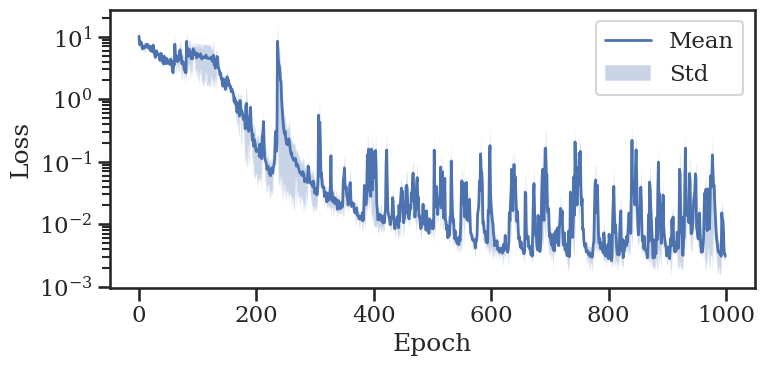

In [4]:
MAX_STEPS = 1000

## Open the train history from one of the runs
folder1 = f"NCF/{df.iloc[9]['folder']}"
train_history1 = np.load(folder1+'/train_histories.npz')['losses_model']

folder2 = f"NCF/{df.iloc[1]['folder']}"
train_history2 = np.load(folder2+'/train_histories.npz')['losses_model']

# plt.plot(train_history)
# plt.yscale('log')


print("Shapes: ", train_history1.shape, train_history2.shape)

train_history = np.stack([train_history1[:MAX_STEPS], train_history2[:MAX_STEPS]], axis=1).squeeze()
# train_history = np.stack([train_history1[:MAX_STEPS], train_history2[::2]], axis=1).squeeze()
print("Train history shape: ", train_history.shape)

## Plot the mean and std with shaded area
plt.figure(figsize=(8, 4))
plt.plot(np.mean(train_history, axis=1), label='Mean')
plt.fill_between(np.arange(train_history.shape[0]), np.mean(train_history, axis=1) - np.std(train_history, axis=1), np.mean(train_history, axis=1) + np.std(train_history, axis=1), alpha=0.3, label='Std')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f'Analysis/ncf_train_history.png')

       Step   Run      Loss
1995  995.0  Run2  0.019084
1996  996.0  Run2  0.010815
1997  997.0  Run2  0.002608
1998  998.0  Run2  0.002692
1999  999.0  Run2  0.002525


Text(0.5, 0, 'Epoch')

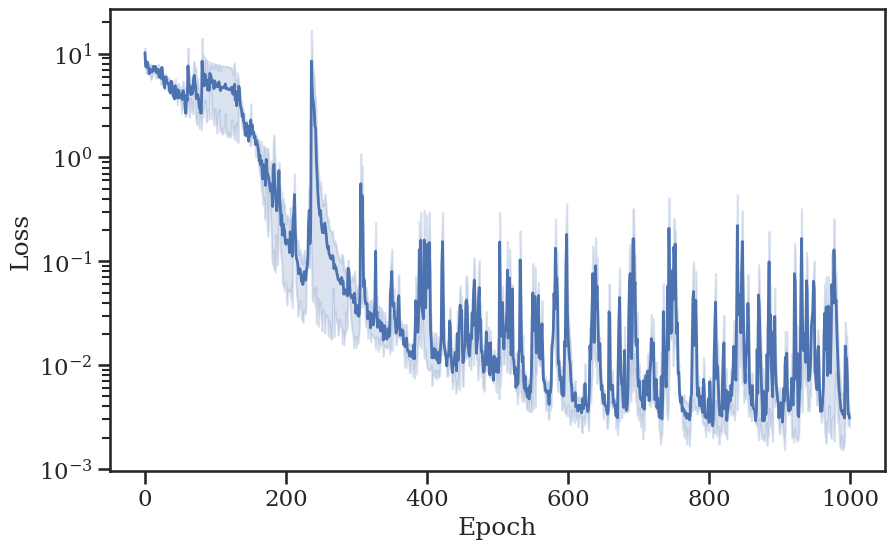

In [5]:
## Do the same things, but using sns.lineplot

## First, put train history in a dataframe, with steps as index (explicitely)
steps = np.arange(train_history.shape[0])
data = np.stack([steps, train_history[:, 0], train_history[:, 1]], axis=1)
df_train = pd.DataFrame(data, columns=['Step', 'Run1', 'Run2'])


## Put the dataset in long format
df_train = df_train.melt(id_vars='Step', var_name='Run', value_name='Loss')
print(df_train.tail())

# ## Next, plot with sns.lineplot
# plt.figure(figsize=(10, 6))
# sns.lineplot(data=df_train, x='Step', y='Run1', label='Run 1')

fig, ax = plt.subplots(figsize=(10, 6))
# ## Plot the mean and std with shaded area
sns.lineplot(data=df_train, x='Step', y='Loss', ax=ax)

ax.set_yscale('log')
ax.set_xlabel('Epoch')

Taylor orders:  [0 1 2 3]
CoDA Min Max:  0.00398 304.0
3 other details:  240922-002125 0 False
3 other details:  240921-171004 0 True
3 other details:  240922-015503 1 False
3 other details:  240921-184231 1 True
3 other details:  240922-032212 2 False
3 other details:  240921-202415 2 True
3 other details:  240922-045410 3 False
3 other details:  240921-222150 3 True


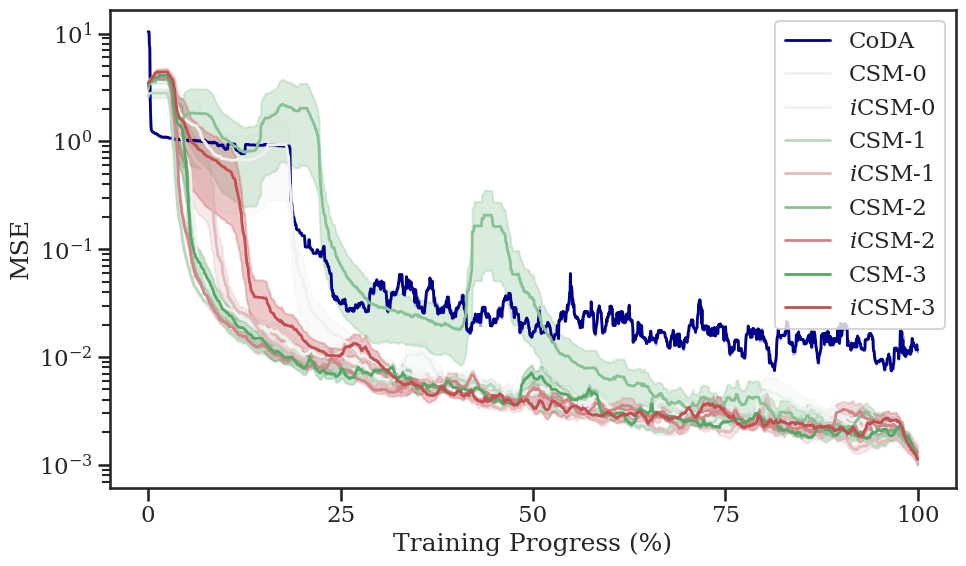

In [6]:
## For each unique combination of taylor_order and indim, plot the mean and std of the loss (without sns)

taylor_orders = df['taylor_order'].unique()
infdims = df['infdim'].unique()
print("Taylor orders: ", taylor_orders)

colors = ['b', 'r', 'g', 'orange', 'brown', 'pink', 'cyan', 'magenta']

shade_scale = 0.5
MAX_STEPS = 2000



fig, ax = plt.subplots(figsize=(10, 6))


## Collect the train histories for CoDA and plot them as well
coda_dat1 = np.load('CoDA/train_histories_1.npz')
epochs, losses1 = coda_dat1['epochs_train'], coda_dat1['loss_train']
coda_dat2 = np.load('CoDA/train_histories_2.npz')
epochs2, losses2 = coda_dat2['epochs_train'], coda_dat2['loss_train']

## Subsample the train history if it is too long
if losses1.shape[0] > MAX_STEPS:
    losses1 = losses1[::losses1.shape[0]//MAX_STEPS]
    losses2 = losses2[::losses2.shape[0]//MAX_STEPS]
    epochs = np.arange(losses1.shape[0])

coda_losses = np.stack([losses1[:], losses2[:]], axis=1)
print("CoDA Min Max: ", np.min(coda_losses), np.max(coda_losses))
coda_losses_smooth = median_filter(coda_losses, 10, mode='nearest')
# print("coda vals: ", coda_losses, "\n", coda_losses_smooth)
coda_mean = np.mean(coda_losses_smooth, axis=1)
coda_std = np.std(coda_losses_smooth, axis=1)
coda_lower = coda_mean - shade_scale*coda_std*1
coda_upper = coda_mean + shade_scale*coda_std*1
ax.plot(coda_mean, label='CoDA', color='darkblue')
ax.fill_between(epochs, coda_lower, coda_upper, alpha=0.3, color='darkblue')




### Now for NCF

for i, to in enumerate(taylor_orders):
    # for j, infd in enumerate(infdims):
    for j, infd in enumerate([False, True]):
        # print(f"Taylor order: {to}, infdim: {infd}")

        ## Get the relevant rows
        rows = df[(df['taylor_order'] == to) & (df['infdim'] == infd)]

        ## Collect the train histories for each row (if they exist)
        train_histories = []
        for k, row in rows.iterrows():
            folder = f"NCF/{row['folder']}"
            if os.path.exists(folder+'/train_histories.npz'):
                train_history = np.load(folder+'/train_histories.npz')['losses_model']

                # # ## Just limit the number of steps
                # train_history = train_history[:MAX_STEPS]

                # ## Subsample the train history if it is too long
                # if train_history.shape[0] > MAX_STEPS:
                #     train_history = train_history[::train_history.shape[0]//MAX_STEPS]

                # train_histories.append(train_history)


                if train_history.shape[0] >= MAX_STEPS:

                    # ## Apply a moving average to smooth the curve
                    window = 100
                    # print("Train history shape: ", train_history.shape)
                    # train_history = np.convolve(train_history.squeeze(), np.ones(window)/window, mode='same')[:, None]
                    train_history = median_filter(train_history.squeeze(), window, mode='constant')[:, None]

                    # ## Apply exponential moving average to smooth the curve
                    # alpha = 0.99
                    # for k in range(1, train_history.shape[0]):
                    #     train_history[k] = alpha*train_history[k-1] + (1-alpha)*train_history[k]

                    train_histories.append(train_history)

        print(len(train_histories), "other details: ", row['folder'], row['taylor_order'], row['infdim'])
        if len(train_histories) == 1:
            print("Other details: ", row['folder'], row['taylor_order'], row['infdim'])

        ## Stack the train histories
        train_histories = np.stack(train_histories, axis=1).reshape(-1, len(train_histories))
        # print("Train histories shape: ", train_histories.shape)

        ## For the color, use shades of red for infd=False, and shades of purple for infd=True. the intensity of the color should depend on the taylor order
        # color = 'flare' if infd == False else 'crest'
        color = 'light:r' if infd == True else 'light:g'
        color = sns.color_palette(color, len(taylor_orders)*1)[1*i]

        # if infd == False:
        ## Plot the mean and std with shaded area
        ax.plot(np.mean(train_histories, axis=1), label=f"$i$CSM-{to}" if infd else f'CSM-{to}', color=color)
        mean = np.mean(train_histories, axis=1)
        std = np.std(train_histories, axis=1)
        lower = mean - shade_scale*std
        upper = mean + shade_scale*std
        ax.fill_between(np.arange(train_histories.shape[0]), lower, upper, alpha=0.3, color=color)

        # ax.fill_between(np.arange(train_histories.shape[0]), np.mean(train_histories, axis=1) - shade_scale*np.std(train_histories, axis=1), np.mean(train_histories, axis=1) + shade_scale*np.std(train_histories, axis=1), alpha=0.1, color=color)




ax.set_yscale('log')
ax.set_ylabel('MSE')

## Turn the x axis into Training Progress (%)
ax.set_xlabel('Training Progress (%)')
ax.set_xticks([0, 500, 1000, 1500, 2000])
ax.set_xticklabels(['0', '25', '50', '75', '100'])

ax.legend()
# ax.set_title(f"Taylor order: {to}, infdim: {infd}")
plt.tight_layout()
plt.savefig(f'Analysis/result.pdf')

In [7]:
# ## Collect the handles and labels for the legend, then plot them separately
# handles, labels = ax.get_legend_handles_labels()
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.legend(handles, labels, loc='upper right')
# plt.tight_layout()
# plt.savefig(f'Analysis/legend.svg')